# Lecture 6, Coupling vegetation and hydrology in a zero-dimensional climate model

This lecture extends the ice-albedo model of Lecture 5 by introducing a biosphere and a hydrological cycle, following Svirezhev and von Bloh (1998). The model builds on two earlier papers by the same authors. Svirezhev and von Bloh (1996) coupled a temperature equation to a vegetation equation and identified up to two stable equilibria, a "dead" planet without vegetation and a "living" planet with vegetation. Svirezhev and von Bloh (1997) added a global carbon cycle as a third state variable and showed that the living branch itself bifurcates into a "cold" and a "hot" vegetated state, giving up to three stable equilibria. Svirezhev and von Bloh (1998), the paper treated here, adds a hydrological cycle on top of this carbon-cycle model: cloudiness and a two-layer albedo scheme are introduced on the climatic side, and the productivity of the biosphere is made to depend on soil moisture on the biotic side.

The notebook introduces each new term before it is used in an equation, and points back to the corresponding piece of the energy balance model from Lecture 4 and Lecture 5 wherever one exists, so that the new model can be read as an extension of that earlier model rather than as an unrelated system. Several entries in the parameter table of the original paper are not fully legible in the scanned version used here, so the parameter values below are chosen to reproduce the reported bifurcation structure rather than to match every published figure to the last decimal.


In [1]:
# Google Colab setup: install the packages this notebook uses.
# Runs only on Colab; skipped in Binder or a local Jupyter install.
import sys
if "google.colab" in sys.modules:
    %pip install -q numpy pandas matplotlib scipy xarray netcdf4 pydap ipywidgets


## 1) Review: the energy balance model of Lectures 4 and 5

Lecture 4 introduced the zero-dimensional energy balance equation

$$C\frac{dT}{dt} = \frac{(1-\alpha)S}{4} - (A - BT) + a\ln\left(\frac{[\text{CO}_2]}{[\text{CO}_2]_{PI}}\right),$$

where $C$ is the heat capacity of the climate system, $S$ is the solar constant, $\alpha$ is a constant planetary albedo, outgoing thermal radiation is represented by the linear fit $A - BT$, $a$ scales the logarithmic CO$_2$ forcing, and $[\text{CO}_2]_{PI}$ is the pre-industrial concentration. Lecture 5 kept this same equation but let the albedo depend on temperature, $\alpha(T)$, stepping from an ice value to an ocean value over a narrow temperature range, which is what produced the ice-albedo feedback and the resulting cold and warm stable states.

The model in this lecture keeps the same left-hand side, a heat capacity multiplying $dT/dt$, and the same idea of albedo depending on the state of the planet. Three things change on the right-hand side, matching the three additional processes this paper wants to represent.

1. Outgoing thermal radiation is written as full Stefan-Boltzmann radiation, $\sigma_{eff}\,T_K^{4}$ (with $T_K$ the absolute temperature), rather than the linear fit $A - BT$, because the paper wants the atmosphere's greenhouse effect to depend explicitly on how much carbon and water vapour it holds, and a fixed linear fit cannot represent that dependence.
2. Albedo depends not just on temperature but on how much vegetation is present and how much moisture the soil holds, because a vegetated, moist surface reflects sunlight differently from a bare, dry one.
3. Two further balance equations are added, one for the carbon held in vegetation and one for atmospheric water, because the whole point of this lecture is to let the biosphere and the hydrological cycle feed back onto temperature rather than being fixed inputs to it.

Because $A$ and $B$ already denote the outgoing-radiation fit constants in Lecture 4, and the paper this lecture follows uses the same two letters for something else entirely, namely the total carbon and total water available to the system, this reuse is worth flagging once and then setting aside: $A$ and $B$ from here on always mean total carbon and total water, following Svirezhev and von Bloh's own notation, and the linear fit $A - BT$ does not reappear in this lecture. The heat capacity keeps the symbol $C$ used in Lecture 4 (though with a different numerical value).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

## 2) Three state variables, two conservation laws

Before writing any new equation, it helps to name the three quantities this lecture tracks and see why there are only three of them rather than five.

The climate is described by the average surface temperature $T$, exactly as before. The biosphere is described by the carbon content of vegetation $N$. The atmosphere holds a total amount of carbon $C_a$ and a water-vapour content $W_a$, both written with the subscript "a" for atmosphere; the soil beneath holds a corresponding water content $W_s$.

This looks like five state variables, $T$, $N$, $C_a$, $W_a$, $W_s$, but two conservation laws cut it down to three. With anthropogenic emissions neglected, the total carbon in the system is conserved,

$$C_a(t) + N(t) = A = \text{const},$$

and, since the planet is assumed to have no ocean, the total water in the system is conserved as well,

$$W_a(t) + W_s(t) = B = \text{const}.$$

These two relations are used to eliminate $C_a$ and $W_s$ throughout, writing $C_a = A - N$ and $W_s = B - W_a$ wherever they are needed. What remains to integrate forward in time are three coupled equations, for $T$, $N$, and $W_a$, and $A$ and $B$, together with the maximum productivity $P_{max}$ introduced in Section 5, are the bifurcation parameters that control how many stable states this system has.

## 3) The temperature equation

### 3.1) Two greenhouse functions, in place of the linear OTR fit

Before writing the temperature equation, two new functions need defining, because they replace the single linear fit $A - BT$ used in Lecture 4. The idea is that the atmosphere's effective emissivity is reduced separately by the carbon it holds and by the water vapour it holds, so two saturating functions are introduced, one per greenhouse agent, following Mokhov and Petoukhov (1978):

$$\varphi_C(C_a) = 1 - C_a\frac{1-\varphi_C^{\infty}}{k_C + C_a}, \qquad \varphi_W(W_a) = \frac{1 + A_W B_W W_a^{\,b_W}}{1 + B_W W_a^{\,b_W}}.$$

Here $\varphi_C^{\infty}$ is the floor the carbon function decays to and $k_C$ is the atmospheric carbon at which $\varphi_C$ has fallen halfway to that floor; $A_W$ is the corresponding floor for the water function, while $B_W$ and $b_W$ set how sharply it drops. With the values used below ($\varphi_C^{\infty} = 0.42$, $k_C = 750$ Gt, $A_W = 0.5$, $B_W = 0.3$, $b_W = 0.5$) both functions equal 1 when their argument is zero — no greenhouse effect — and decay towards their floor as $C_a$ or $W_a$ grows, so the greenhouse effect strengthens but eventually stops responding to further increases.

Together they set the atmosphere's effective emissivity,

$$\sigma_{eff} = \sigma\,\varphi_C(C_a)\,\varphi_W(W_a),$$

where $\sigma = 5.67\times10^{-8}\ \text{W m}^{-2}\,\text{K}^{-4}$ is the Stefan–Boltzmann constant. The product $\sigma_{eff}$ takes the place of the fixed coefficients $A$ and $B$ of the linear OTR fit.

### 3.2) Cloudiness, needed for both radiation and albedo

A second new quantity, cloudiness $n$, is needed before the temperature equation can be written, because it appears in the radiative loss term below and will reappear in the albedo of Section 4. Cloudiness is diagnosed from relative humidity $q = W_a / W_a^{*}(T)$. The saturated water-vapour concentration $W_a^{*}(T)$ is taken from a Magnus-form approximation to the Clausius-Clapeyron relation,

$$W_a^{*}(T) = \exp\!\left(\frac{17.638\,T}{T + 243.4}\right),$$

with the temperature $T$ in degrees Celsius. It is normalised so that $W_a^{*} = 1$ at $T = 0$, and roughly doubles for every 10°C of warming, which is what makes relative humidity, and hence cloudiness, so sensitive to temperature. Cloudiness $n$ then follows Smagorinsky (1960):

$$n = \begin{cases} 2q - 1, & 0.5 \le q \le 1 \\ 0, & 0 \le q < 0.5. \end{cases}$$

In words, the atmosphere is taken to be cloud-free below 50% relative humidity, and cloudiness rises linearly to 1 as saturation is approached.

### 3.3) The temperature equation itself

With $\varphi_C$, $\varphi_W$, and $n$ defined, the temperature equation, taken from Petoukhov and Ganopolski (1994), can now be written in the same form as the Lecture 4 equation, heat capacity times $dT/dt$ on the left, absorbed minus outgoing radiation on the right:

$$C\frac{dT}{dt} = S\,(1-\alpha) - \sigma_{eff}\,T_K^{4} - k_W\,W_a\,n,$$

where $C$ is the surface heat capacity; $S \approx 340\ \text{W m}^{-2}$ is the incoming solar flux, already the whole-sphere average, so unlike the Lecture 4 equation there is no division by four; $\alpha$ is the surface albedo built in Section 4; $T_K = T + 273.15$ is the absolute temperature that enters the Stefan–Boltzmann term (while $T$ in degrees Celsius is used everywhere else); and $k_W = 0.4$ weights a small extra cooling proportional to the cloudy part of the atmospheric water content.


In [3]:
S        = 340.0     # solar radiation, W/m2
sigma    = 5.67e-8   # Stefan-Boltzmann constant
kW       = 0.4       # latent heat weighting
C_heat   = 6.0        # surface heat capacity, year-scaled

phiC_inf = 0.42       # saturation level of the carbon greenhouse function
kC       = 750.0      # half-saturation, Gt

AW, BW, bw = 0.50, 0.30, 0.50   # water-vapour greenhouse function parameters


def phiC(Ca):
    """Greenhouse function of atmospheric carbon, Mokhov and Petoukhov (1978)."""
    return 1.0 - Ca * (1.0 - phiC_inf) / (kC + Ca)


def phiW(Wa):
    """Greenhouse function of atmospheric water vapour."""
    x = max(Wa, 1e-6) ** bw
    return (1.0 + AW * BW * x) / (1.0 + BW * x)


def Wa_sat(T):
    """Saturated water-vapour concentration: Magnus-form Clausius-Clapeyron,
    normalised to Wa_sat(0 deg C) = 1."""
    return np.exp(17.638 * T / (T + 243.4))


def cloudiness(T, Wa):
    """Cloudiness as a function of relative humidity, Smagorinsky (1960)."""
    q = np.clip(Wa / Wa_sat(T), 0.0, 1.0)
    return np.clip(2.0 * q - 1.0, 0.0, 1.0)


### Visualising the greenhouse functions (Section 3.1)

Both greenhouse functions equal 1 when their greenhouse agent is absent and decay
towards a floor as it accumulates: $\varphi_C \to \varphi_C^{\infty} = 0.42$ as
atmospheric carbon $C_a$ grows, and $\varphi_W \to A_W = 0.5$ as atmospheric water
$W_a$ grows. Their product is the effective emissivity
$\varepsilon_{eff} = \varphi_C\,\varphi_W$ that multiplies $\sigma\,T_K^4$ in the
temperature equation of Section 3.3: a smaller $\varepsilon_{eff}$ means a stronger
greenhouse effect and less efficient radiative cooling to space.


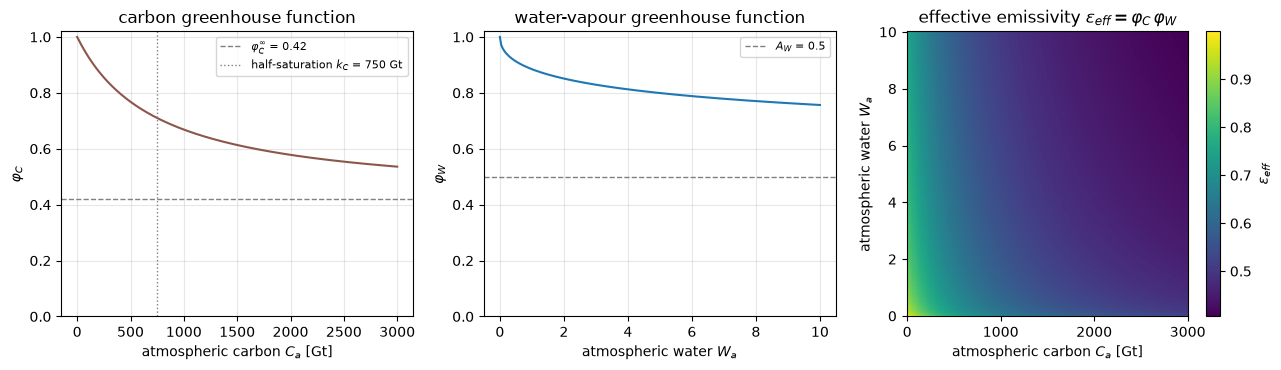

In [4]:
phiW_vec = np.vectorize(phiW)          # phiW is written for scalar input

Ca_axis = np.linspace(0.0, 3000.0, 250)   # atmospheric carbon, Gt
Wa_axis = np.linspace(0.0, 10.0, 250)     # atmospheric water

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# phi_C(Ca): carbon greenhouse function
axes[0].plot(Ca_axis, phiC(Ca_axis), color="tab:brown")
axes[0].axhline(phiC_inf, ls="--", color="grey", lw=1,
                label=fr"$\varphi_C^\infty$ = {phiC_inf}")
axes[0].axvline(kC, ls=":", color="grey", lw=1,
                label=f"half-saturation $k_C$ = {kC:.0f} Gt")
axes[0].set_xlabel("atmospheric carbon $C_a$ [Gt]")
axes[0].set_ylabel(r"$\varphi_C$")
axes[0].set_title("carbon greenhouse function")
axes[0].set_ylim(0.0, 1.02)
axes[0].legend(fontsize=8)

# phi_W(Wa): water-vapour greenhouse function
axes[1].plot(Wa_axis, phiW_vec(Wa_axis), color="tab:blue")
axes[1].axhline(AW, ls="--", color="grey", lw=1, label=fr"$A_W$ = {AW}")
axes[1].set_xlabel("atmospheric water $W_a$")
axes[1].set_ylabel(r"$\varphi_W$")
axes[1].set_title("water-vapour greenhouse function")
axes[1].set_ylim(0.0, 1.02)
axes[1].legend(fontsize=8)

# effective emissivity eps_eff = phi_C * phi_W over the (Ca, Wa) plane
CA, WA = np.meshgrid(Ca_axis, Wa_axis)
eps_eff = phiC(CA) * phiW_vec(WA)
pc = axes[2].pcolormesh(Ca_axis, Wa_axis, eps_eff, shading="auto", cmap="viridis")
axes[2].set_xlabel("atmospheric carbon $C_a$ [Gt]")
axes[2].set_ylabel("atmospheric water $W_a$")
axes[2].set_title(r"effective emissivity $\varepsilon_{eff} = \varphi_C\,\varphi_W$")
fig.colorbar(pc, ax=axes[2], label=r"$\varepsilon_{eff}$")

for ax in axes[:2]:
    ax.grid(alpha=0.3)
fig.tight_layout()


### Visualising saturation vapour and cloudiness (Section 3.2)

Relative humidity is $q = W_a / W_a^{*}(T)$, where the saturated water-vapour
concentration $W_a^{*}(T)$ follows the Clausius-Clapeyron relation and rises steeply
with temperature. Cloudiness $n$ is then zero below 50% relative humidity and rises
linearly to 1 as the air approaches saturation. The same $n$ feeds both the radiative
loss term in Section 3.3 and the albedo in Section 4.


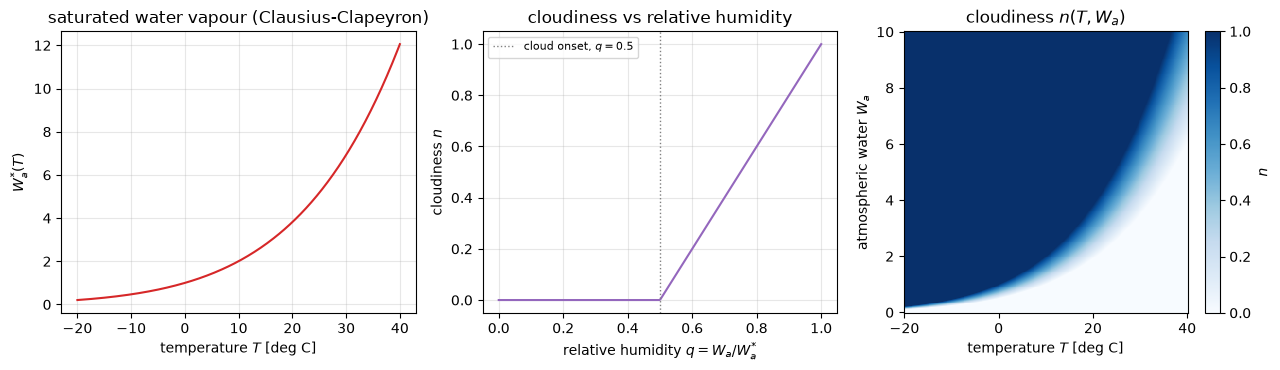

In [5]:
T_axis = np.linspace(-20.0, 40.0, 300)    # temperature, deg C
q_axis = np.linspace(0.0, 1.0, 300)       # relative humidity

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# saturated water-vapour concentration (Clausius-Clapeyron)
axes[0].plot(T_axis, Wa_sat(T_axis), color="tab:red")
axes[0].set_xlabel("temperature $T$ [deg C]")
axes[0].set_ylabel(r"$W_a^{*}(T)$")
axes[0].set_title("saturated water vapour (Clausius-Clapeyron)")

# cloudiness as a function of relative humidity
axes[1].plot(q_axis, np.clip(2.0 * q_axis - 1.0, 0.0, 1.0), color="tab:purple")
axes[1].axvline(0.5, ls=":", color="grey", lw=1, label="cloud onset, $q = 0.5$")
axes[1].set_xlabel(r"relative humidity $q = W_a / W_a^{*}$")
axes[1].set_ylabel("cloudiness $n$")
axes[1].set_title("cloudiness vs relative humidity")
axes[1].legend(fontsize=8)

# cloudiness over the (T, Wa) plane
Wa_axis = np.linspace(0.0, 10.0, 300)
TT, WW = np.meshgrid(T_axis, Wa_axis)
n_field = cloudiness(TT, WW)
pc = axes[2].pcolormesh(T_axis, Wa_axis, n_field, shading="auto",
                        cmap="Blues", vmin=0.0, vmax=1.0)
axes[2].set_xlabel("temperature $T$ [deg C]")
axes[2].set_ylabel("atmospheric water $W_a$")
axes[2].set_title(r"cloudiness $n(T, W_a)$")
fig.colorbar(pc, ax=axes[2], label="$n$")

for ax in axes[:2]:
    ax.grid(alpha=0.3)
fig.tight_layout()


## 4) Albedo: from a step function to a vegetated, snow-covered surface

Lecture 5 already made albedo depend on the state of the planet, stepping between an ice value and an ocean value as temperature crossed a narrow range. This section builds a more detailed albedo, still state-dependent, but now also sensitive to how much vegetation is present and how moist the soil is, following Svirezhev and von Bloh rather than the step-like ice line of Budyko (1969).

Three new quantities need defining before the albedo itself can be written down, each answering a specific question about the surface.

**How much of the land is bare, rather than vegetated?** This is given by a share of land not covered by vegetation, $\lambda(N)$, a decreasing function of vegetation carbon $N$: the more vegetation, the smaller the bare fraction.

$$\lambda(N) = 1 - \frac{N}{k_a + N},$$

where $k_a = 600$ Gt is the vegetation carbon at which the bare fraction has fallen to one half.

**How much of the land is under snow?** This is given by a share of land covered by snow, $f_{sn}(T)$, a smooth, piecewise-linear function of temperature that replaces the harder ice-line threshold of Lecture 5 and of Budyko (1969):

$$f_{sn}(T) = \begin{cases} 1, & T < -15^{\circ}\text{C} \\ 1 - \dfrac{T+15}{30}, & -15^{\circ}\text{C} \le T < 15^{\circ}\text{C} \\ 0, & T \ge 15^{\circ}\text{C}. \end{cases}$$

**How does bare-soil albedo depend on moisture?** Dry soil reflects more than wet soil, so a factor $f_{bs}$ scales the dry-soil albedo down as the relative soil moisture $W_s/W_s^{*}$ rises towards saturation,

$$f_{bs}\!\left(\frac{W_s}{W_s^{*}}\right) = 1 - \frac{W_s}{W_s^{*}}\left(1 - f_{bs}^{\infty}\right),$$

a straight line from $1$ for bone-dry soil to $f_{bs}^{\infty} = 0.5$ at saturation. Here $W_s^{*} = 20\ \text{g cm}^{-2}$ is the soil-moisture content at saturation.

Write $\alpha_{veg} = 0.10$ for a fully vegetated surface, $\alpha_{sn} = 0.70$ for snow, and $\alpha_{bs} = \alpha_{bs}^{0}\,f_{bs}(W_s/W_s^{*})$ for the moisture-adjusted bare soil, with dry-soil value $\alpha_{bs}^{0} = 0.40$. Using the same cloudiness $n$ as in Section 3.2, the albedo is then built up in two layers: a snow-free surface mixing bare soil and vegetation, blended with snow, and finally blended with a cloud layer,

$$\alpha_{surf} = \big[\lambda(N)\,\alpha_{bs} + (1-\lambda(N))\,\alpha_{veg}\big](1-f_{sn}) + \alpha_{sn}\,f_{sn}, \qquad \alpha = 0.1 + 0.4\,n + \alpha_{surf}\,(0.81 - 0.56\,n).$$

The bare numbers in the second expression are fixed cloud-optics coefficients: $0.1 + 0.4\,n$ is the brightness of the cloud layer itself as a function of its fractional cover $n$, and the factor $0.81 - 0.56\,n$ is how much of the surface below still shows through.


In [6]:
aveg, abs0, asn = 0.10, 0.40, 0.70   # albedo of vegetation, dry bare soil, snow
ka       = 600.0     # Gt, half-saturation of lambda(N)
fbs_star = 0.5        # asymptotic soil-albedo factor at saturation


def lam(N):
    """Share of land not covered by vegetation."""
    return 1.0 - N / (ka + N)


def fsn(T):
    """Share of land covered by snow."""
    if T < -15.0:
        return 1.0
    if T < 15.0:
        return 1.0 - (T + 15.0) / 30.0
    return 0.0


def fbs(frac):
    """Dependence of bare-soil albedo on relative soil moisture."""
    frac = np.clip(frac, 0.0, 1.0)
    return 1.0 - frac * (1.0 - fbs_star)


def albedo(T, N, Wa, Ws):
    n = cloudiness(T, Wa)
    l = lam(N)
    a_bs = abs0 * fbs(Ws / Ws_star)
    fsn_ = fsn(T)
    a_surf = (l * a_bs + (1 - l) * aveg) * (1 - fsn_) + asn * fsn_
    a = 0.1 + 0.4 * n + a_surf * (0.81 - 0.56 * n)
    return a, n

### Visualising the albedo scheme (Section 4)

The surface albedo is built from three ingredients: the bare-land fraction
$\lambda(N)$, which falls as vegetation grows; the snow-covered fraction $f_{sn}(T)$,
which drops linearly from 1 to 0 between $-15$ and $15$&nbsp;&deg;C; and the bare-soil
albedo factor $f_{bs}$, which darkens the soil as it wets. The fourth panel shows the
planetary albedo $\alpha$ that results, as a function of temperature and vegetation
carbon (at fixed atmospheric water and soil moisture): it is high where the surface is
snow-covered and low where it is warm and vegetated.


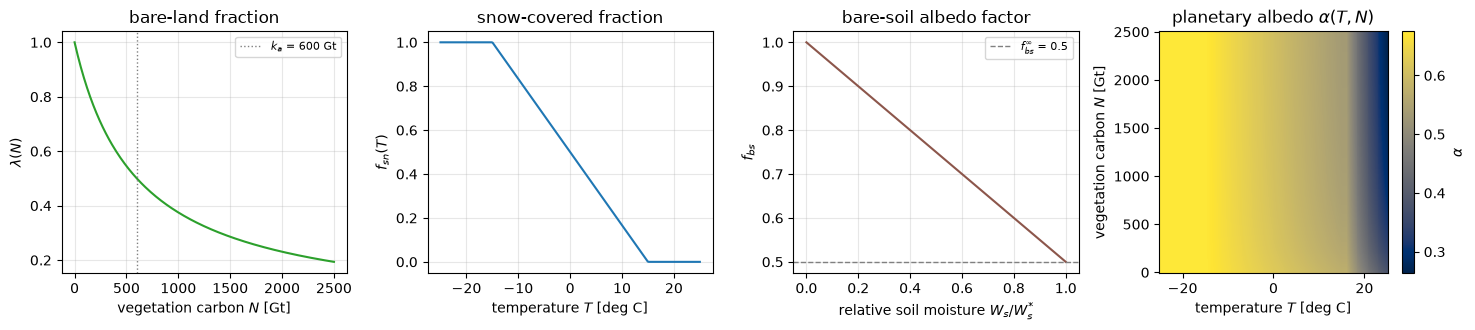

In [7]:
fsn_vec = np.vectorize(fsn)          # fsn is written for scalar input
Ws_star = 20.0                       # saturated soil moisture (also set in Section 5)

N_axis = np.linspace(0.0, 2500.0, 250)     # vegetation carbon, Gt
T_axis = np.linspace(-25.0, 25.0, 250)     # temperature, deg C
m_axis = np.linspace(0.0, 1.0, 250)        # relative soil moisture Ws / Ws*

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

axes[0].plot(N_axis, lam(N_axis), color="tab:green")
axes[0].axvline(ka, ls=":", color="grey", lw=1, label=f"$k_a$ = {ka:.0f} Gt")
axes[0].set_xlabel("vegetation carbon $N$ [Gt]")
axes[0].set_ylabel(r"$\lambda(N)$")
axes[0].set_title("bare-land fraction")
axes[0].legend(fontsize=8)

axes[1].plot(T_axis, fsn_vec(T_axis), color="tab:blue")
axes[1].set_xlabel("temperature $T$ [deg C]")
axes[1].set_ylabel(r"$f_{sn}(T)$")
axes[1].set_title("snow-covered fraction")

axes[2].plot(m_axis, fbs(m_axis), color="tab:brown")
axes[2].axhline(fbs_star, ls="--", color="grey", lw=1,
                label=fr"$f_{{bs}}^{{\infty}}$ = {fbs_star}")
axes[2].set_xlabel(r"relative soil moisture $W_s / W_s^{*}$")
axes[2].set_ylabel(r"$f_{bs}$")
axes[2].set_title("bare-soil albedo factor")
axes[2].legend(fontsize=8)

albedo_a = np.vectorize(lambda T, N: albedo(T, N, 3.0, 10.0)[0])   # Wa = 3, Ws = 10
TT, NN = np.meshgrid(T_axis, N_axis)
alpha_field = albedo_a(TT, NN)
pc = axes[3].pcolormesh(T_axis, N_axis, alpha_field, shading="auto", cmap="cividis")
axes[3].set_xlabel("temperature $T$ [deg C]")
axes[3].set_ylabel("vegetation carbon $N$ [Gt]")
axes[3].set_title(r"planetary albedo $\alpha(T, N)$")
fig.colorbar(pc, ax=axes[3], label=r"$\alpha$")

for ax in axes[:3]:
    ax.grid(alpha=0.3)
fig.tight_layout()


## 5) Vegetation: a new state variable, needing its own balance equation

Everything so far has adapted the climate side of Lecture 5's model. This section introduces the biosphere itself, which Lecture 5 did not have. Vegetation carbon $N$ needs its own balance equation because it is gained through productivity and lost through turnover, exactly as the temperature above is gained through absorbed radiation and lost through emitted radiation:

$$\frac{dN}{dt} = P - mN,$$

where $m = 1/\tau_N$ is the inverse residence time of living biomass and $P$ is the annual net productivity, still to be defined.

Before writing $P$, three limitation functions need naming, one per resource that can limit plant growth, following the Liebig principle as formalised by Keeling (1973): a function of temperature $g_T$, a function of available carbon $g_C$, a function of standing vegetation $g_N$, and a function of soil moisture $g_W$, combined multiplicatively so that growth is throttled by whichever resource is scarcest,

$$P = P_{max}\, g_T(T)\, g_C(C_a)\, g_N(N)\, g_W(W_s).$$

$g_C(A-N)$ is increasing in available carbon and $g_N(N)$ is increasing in existing vegetation up to a point, so Svirezhev and von Bloh merge the two into a single unimodal function of $N$ alone,

$$G_N(N) = g_C(A-N)\,g_N(N) = \frac{4N(A-N)}{A^2},$$

which is zero when there is no vegetation, zero again when vegetation has consumed essentially all the carbon in the system, and largest at $N = A/2$.

$g_T$ and $g_W$ have the same shape: a downward parabola scaled to equal $1$ at the midpoint of a tolerance interval and falling to $0$ at its two endpoints, held at $0$ everywhere outside the interval,

$$g_T(T) = \begin{cases} \dfrac{4\,(T - T_1)(T_2 - T)}{(T_2 - T_1)^2}, & T_1 \le T \le T_2 \\ 0, & \text{otherwise}, \end{cases} \qquad g_W(W_s) = \begin{cases} \dfrac{4\,(W_s - W_{s1})(W_{s2} - W_s)}{(W_{s2} - W_{s1})^2}, & W_{s1} \le W_s \le W_{s2} \\ 0, & \text{otherwise}. \end{cases}$$

The limits used here are $[T_1, T_2] = [5, 40]$ &deg;C for temperature and $[W_{s1}, W_{s2}] = [1, 18]$ g cm$^{-2}$ for soil moisture. Outside either range the corresponding factor is zero and productivity stops altogether, so vegetation cannot grow if it is too cold, too hot, too dry, or too waterlogged. Like $G_N$, each factor peaks at its interval midpoint &mdash; $22.5$ &deg;C and $9.5$ g cm$^{-2}$ &mdash; taken here as ideal growing conditions.


In [8]:
m_turn   = 0.03    # 1/year, vegetation turnover rate
T1, T2   = 5.0, 40.0        # deg C, thermal tolerance of vegetation
Ws1, Ws2 = 1.0, 18.0        # g/cm2, soil-moisture tolerance of vegetation
Ws_star  = 20.0             # g/cm2, saturated soil moisture
Pmax_default = 60.0         # Gt/yr, maximum productivity


def gT(T):
    return 4 * (T - T1) * (T2 - T) / (T2 - T1) ** 2 if T1 <= T <= T2 else 0.0


def GN(N, A):
    N = np.clip(N, 0.0, A)
    return 4 * N * (A - N) / A ** 2


def gW(Ws):
    return 4 * (Ws - Ws1) * (Ws2 - Ws) / (Ws2 - Ws1) ** 2 if Ws1 <= Ws <= Ws2 else 0.0


def productivity(T, N, Ws, A, Pmax):
    return Pmax * gT(T) * GN(N, A) * gW(Ws)

### Visualising the productivity functions (Section 5)

Net productivity is the product of three limitation factors, each between 0 and 1:
$g_T(T)$ for temperature, $g_W(W_s)$ for soil moisture, and $G_N(N)$ for the carbon
available to and held by vegetation. Each is a downward parabola, non-zero only inside
its tolerance band (shaded). The fourth panel shows the productivity $P$ over the
temperature–moisture plane at $N = A/2$: growth is confined to a window that is
neither too cold, too hot, too dry, nor too wet.


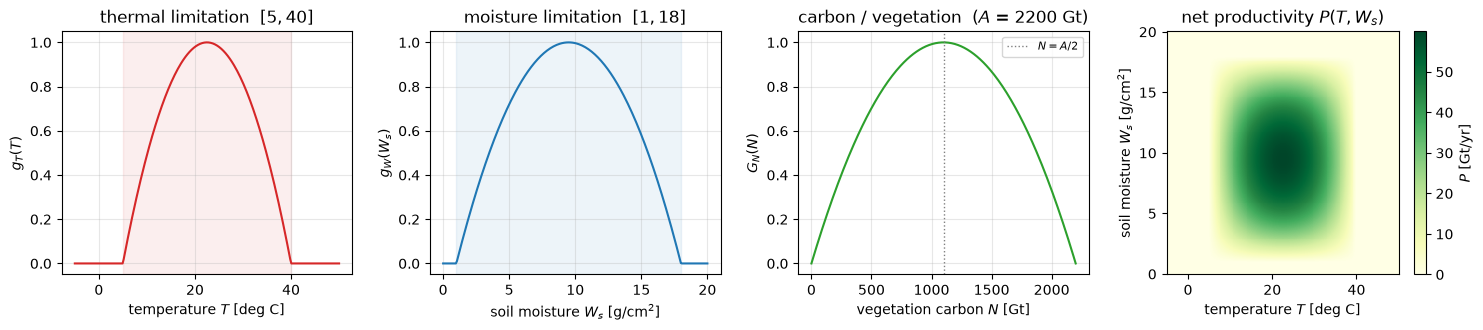

In [9]:
gT_vec = np.vectorize(gT)            # gT, gW are written for scalar input
gW_vec = np.vectorize(gW)

A_demo = 2200.0                             # total carbon, Gt
T_axis = np.linspace(-5.0, 50.0, 250)       # temperature, deg C
Ws_axis = np.linspace(0.0, 20.0, 250)       # soil moisture, g/cm2
N_axis = np.linspace(0.0, A_demo, 250)      # vegetation carbon, Gt

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

axes[0].plot(T_axis, gT_vec(T_axis), color="tab:red")
axes[0].axvspan(T1, T2, color="tab:red", alpha=0.08)
axes[0].set_xlabel("temperature $T$ [deg C]")
axes[0].set_ylabel(r"$g_T(T)$")
axes[0].set_title(f"thermal limitation  $[{T1:.0f}, {T2:.0f}]$")

axes[1].plot(Ws_axis, gW_vec(Ws_axis), color="tab:blue")
axes[1].axvspan(Ws1, Ws2, color="tab:blue", alpha=0.08)
axes[1].set_xlabel(r"soil moisture $W_s$ [g/cm$^2$]")
axes[1].set_ylabel(r"$g_W(W_s)$")
axes[1].set_title(f"moisture limitation  $[{Ws1:.0f}, {Ws2:.0f}]$")

axes[2].plot(N_axis, GN(N_axis, A_demo), color="tab:green")
axes[2].axvline(A_demo / 2, ls=":", color="grey", lw=1, label="$N = A/2$")
axes[2].set_xlabel("vegetation carbon $N$ [Gt]")
axes[2].set_ylabel(r"$G_N(N)$")
axes[2].set_title(f"carbon / vegetation  ($A$ = {A_demo:.0f} Gt)")
axes[2].legend(fontsize=8)

TT, WW = np.meshgrid(T_axis, Ws_axis)
P_field = np.vectorize(productivity)(TT, A_demo / 2, WW, A_demo, Pmax_default)
pc = axes[3].pcolormesh(T_axis, Ws_axis, P_field, shading="auto", cmap="YlGn")
axes[3].set_xlabel("temperature $T$ [deg C]")
axes[3].set_ylabel(r"soil moisture $W_s$ [g/cm$^2$]")
axes[3].set_title(r"net productivity $P(T, W_s)$")
fig.colorbar(pc, ax=axes[3], label="$P$ [Gt/yr]")

for ax in axes[:3]:
    ax.grid(alpha=0.3)
fig.tight_layout()


## 6) The hydrological cycle: closing the third balance equation

The last new balance equation needed is for atmospheric water $W_a$, and it is built the same way as the vegetation equation just introduced, as a gain term minus a loss term. Two new quantities need defining first.

**Precipitation** $H$ is proportional to the product of atmospheric water and cloudiness,

$$H = \frac{n_a\,W_a\,n}{B},$$

with the same cloudiness $n$ as in Section 3.2, a rate coefficient $n_a = 70\ \text{yr}^{-1}$, and the total water $B$ entering as a normalisation. A wetter, cloudier atmosphere rains more.

**Evaporation** $E$ combines two sources, weighted by the land-cover fraction $\lambda(N)$ of Section 4. Bare soil evaporates at a rate set by the vapour deficit and the wetness of the soil,

$$E_{bs} = \big[W_a^{*}(T) - W_a\big]^{+}\,\frac{W_s}{W_s^{*}},$$

where $[\,\cdot\,]^{+}$ denotes the positive part (there is no condensation back onto the soil). Vegetation transpires in proportion to its productivity,

$$E_{veg} = n_{veg}\,P,$$

with $n_{veg} = 0.03$ and $P$ the net productivity of Section 5. The two combine as

$$E = \lambda(N)\,E_{bs} + [1-\lambda(N)]\,E_{veg}, \qquad \frac{dW_a}{dt} = -H + E.$$

With $H$ and $E$ defined, all three right-hand sides, for $T$, $N$, and $W_a$, can be collected into a single function that a numerical solver can integrate forward in time.


In [10]:
na_coef = 70.0    # 1/year, precipitation coefficient
nveg    = 0.03    # evapotranspiration coefficient


def rhs(t, y, A, B, Pmax):
    T, N, Wa = y
    N = np.clip(N, 1e-6, A - 1e-6)
    Wa = np.clip(Wa, 1e-6, B - 1e-6)
    Ws = B - Wa
    Ca = A - N

    a, n = albedo(T, N, Wa, Ws)
    sigma_eff = sigma * phiC(Ca) * phiW(Wa)
    TK = T + 273.15
    dT = (S * (1 - a) - sigma_eff * TK ** 4 - kW * Wa * n) / C_heat

    P = productivity(T, N, Ws, A, Pmax)
    dN = P - m_turn * N

    H = na_coef * Wa * n / B
    Ebs = max(Wa_sat(T) - Wa, 0.0) * Ws / Ws_star
    Eveg = nveg * P
    E = lam(N) * Ebs + (1 - lam(N)) * Eveg
    dWa = -H + E

    return [dT, dN, dWa]


def run(T0, N0, Wa0, A, B, t_end=300.0, Pmax=Pmax_default):
    return solve_ivp(rhs, [0, t_end], [T0, N0, Wa0], args=(A, B, Pmax),
                      method="Radau", dense_output=True, max_step=2.0)


def classify(T_final, N_final, N_tol=5.0):
    """Coarse label for a final state, used to count distinct equilibria."""
    if N_final < N_tol:
        return "dead"
    return "cold-living" if T_final < 5.0 else "warm-living" 

Because the water, temperature, and vegetation subsystems relax on very different time scales ($\tau_W \ll \tau_T \ll \tau_N$), the paper notes that the system must be integrated with a stiff solver; the same choice, an implicit Radau method, is made here.

### 6.1) A single pair of trajectories

The cell below starts two integrations from the same temperature but from different amounts of standing vegetation, at a fixed total carbon $A = 2200$ Gt. The two trajectories converge onto the same warm, vegetated equilibrium, though along different paths: the run that starts bare warms up first, before enough vegetation has grown to cool the planet back down through increased evapotranspiration and altered albedo, while the already-vegetated run relaxes to the equilibrium directly.

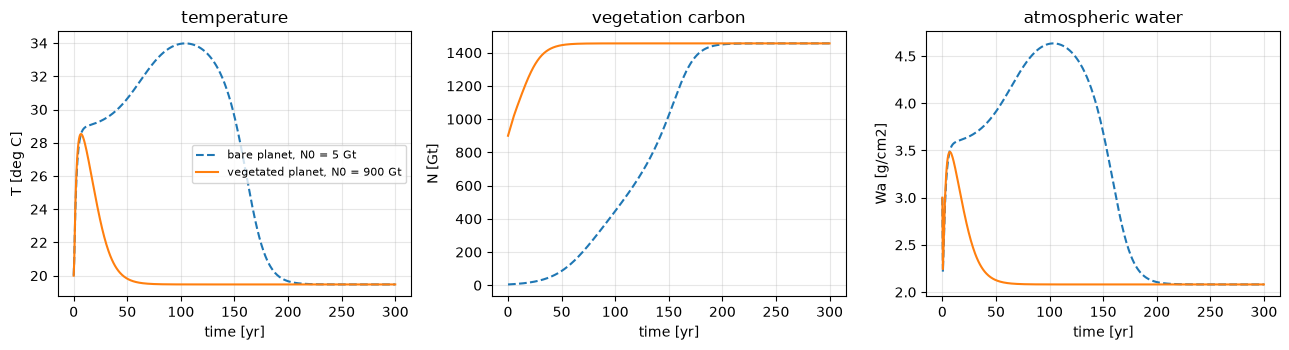

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
A_demo, B_demo = 2200.0, 15.0
t_plot = np.linspace(0, 300, 600)
for N0, style, label in [(5.0, "--", "bare planet, N0 = 5 Gt"),
                          (900.0, "-", "vegetated planet, N0 = 900 Gt")]:
    sol = run(T0=20.0, N0=N0, Wa0=3.0, A=A_demo, B=B_demo, t_end=300)
    Y = sol.sol(t_plot)
    axes[0].plot(t_plot, Y[0], style, label=label)
    axes[1].plot(t_plot, Y[1], style, label=label)
    axes[2].plot(t_plot, Y[2], style, label=label)
axes[0].set_ylabel("T [deg C]"); axes[0].set_xlabel("time [yr]"); axes[0].set_title("temperature")
axes[1].set_ylabel("N [Gt]"); axes[1].set_xlabel("time [yr]"); axes[1].set_title("vegetation carbon")
axes[2].set_ylabel("Wa [g/cm2]"); axes[2].set_xlabel("time [yr]"); axes[2].set_title("atmospheric water")
axes[0].legend(fontsize=8, loc="center right")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()

## 7) Basins of attraction depend on the total amount of carbon

Svirezhev and von Bloh show, in their Fig. 11, that the number and identity of stable equilibria change as the total carbon $A$ is increased at fixed total water $B$: at low $A$ only a cold, vegetation-free desert is stable; at intermediate $A$ the desert coexists with a vegetated state, so that the outcome depends on where the system starts; at high $A$ the desert disappears and only the vegetated state remains stable. This is the same kind of multistability seen in Lecture 5, where the bifurcation parameter was solar insolation rather than the total carbon budget; the cell below produces an analogous diagram by integrating a grid of initial temperatures and initial vegetation amounts to their final state, for four increasing values of $A$, and colouring each starting point by the equilibrium it reaches.


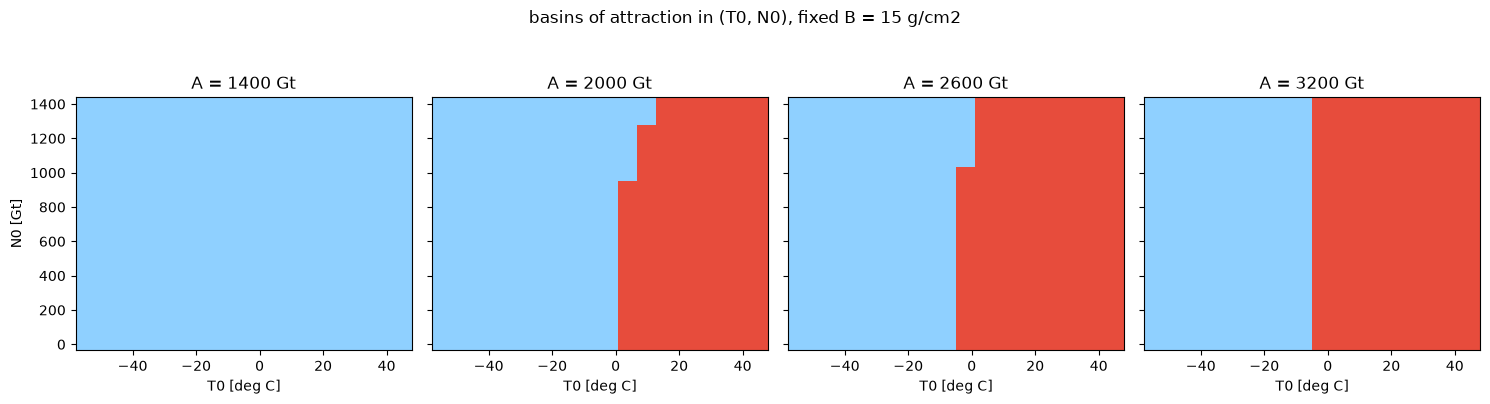

In [12]:
T0_grid = np.linspace(-55, 45, 18)
N0_grid = np.linspace(5, 1400, 18)
A_values = [1400.0, 2000.0, 2600.0, 3200.0]
B_fixed = 15.0

colour_map = {"dead": 0, "cold-living": 1, "warm-living": 2}
cmap = matplotlib.colors.ListedColormap(["#8fd0ff", "#2ecc71", "#e74c3c"])

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharex=True, sharey=True)
for ax, A in zip(axes, A_values):
    grid = np.zeros((len(N0_grid), len(T0_grid)))
    for i, N0 in enumerate(N0_grid):
        for j, T0 in enumerate(T0_grid):
            sol = run(T0=T0, N0=N0, Wa0=3.0, A=A, B=B_fixed, t_end=250)
            Tf, Nf, _ = sol.y[:, -1]
            grid[i, j] = colour_map[classify(Tf, Nf)]
    ax.pcolormesh(T0_grid, N0_grid, grid, cmap=cmap, vmin=0, vmax=2, shading="nearest")
    ax.set_title(f"A = {A:.0f} Gt")
    ax.set_xlabel("T0 [deg C]")
axes[0].set_ylabel("N0 [Gt]")
fig.suptitle(f"basins of attraction in (T0, N0), fixed B = {B_fixed:.0f} g/cm2", y=1.05)
fig.tight_layout()

**How to read it.** Each panel fixes the total carbon $A$ (rising from left to right)
at the fixed total water $B = 15$. Inside a panel every pixel is one 250-year model
run: its horizontal position is the *initial* temperature $T_0$, its vertical position
is the *initial* vegetation carbon $N_0$, and its colour is the state the run settles
into &mdash; blue for the cold, vegetation-free **desert**, red for the warm,
**vegetated** state. Reading down a column shows what happens to planets that start at
the same temperature but with different amounts of vegetation; reading along a row
shows the effect of the starting temperature at fixed initial vegetation.

**What the panels show.**

- **$A = 1400$ Gt:** the whole plane is blue. There is not enough carbon in the system
  for vegetation to persist, so every starting point &mdash; even a warm, fully
  forested planet &mdash; collapses to desert. The desert is the *only* stable state.
- **$A = 2000$ Gt:** a red region appears on the warm side. The blue&ndash;red boundary
  is close to vertical, so the outcome is set mostly by initial *temperature*, but it
  has a clear step: starting from little vegetation a planet needs $T_0 \approx
  13\,^{\circ}$C to end up green, whereas starting with a large standing stock
  ($N_0 \gtrsim 1000$ Gt) it survives from as cool as $T_0 \approx 1\,^{\circ}$C. In
  that wedge the *same* climate gives *two* outcomes depending on the initial
  vegetation &mdash; this is **bistability**.
- **$A = 2600$ and $3200$ Gt:** the red region keeps growing and its edge moves left,
  until at $A = 3200$ almost any start above the freezing line ends vegetated
  regardless of $N_0$. The vegetated branch has taken over; the desert survives only
  where it is simply too cold for plants.

**What we infer.**

1. **Total carbon is a control parameter.** Raising $A$ carries the system from *only
   desert* &rarr; *desert or forest, depending on history* &rarr; *only forest*. This
   is a bifurcation &mdash; the vegetation-model counterpart of the solar-insolation
   bifurcation of Lecture 5.
2. **The biosphere gives the climate a memory.** Wherever blue and red share a column,
   the planet's fate is decided by its past, not its climate: an existing forest lowers
   the albedo and recycles enough moisture to sustain itself, while a bare planet in
   the identical climate stays bare, and neither can be nudged into the other by a
   small perturbation.
3. **The cold half is unconditionally dead.** Below roughly the freezing line the
   snow-albedo feedback dominates and the starting vegetation is irrelevant &mdash; the
   same cold-desert branch met in Lecture 5.
4. **Reading it for the real world.** A system sitting in the bistable wedge is exactly
   the kind that can be tipped &mdash; by clearing the vegetation, or by a drought that
   kills it &mdash; into a state it will not recover from on its own. This is the
   tipping-point behaviour of Lecture 2, here for a vegetated planet.


## 8) Counting stable states in the (A, B) plane

Svirezhev and von Bloh summarise the bifurcation structure of the full model in their Fig. 12, a map of the number of stable equilibria over the $(A, B)$ parameter plane, for fixed maximum productivity $P_{max}$, playing the same role that a map of equilibrium temperature against solar insolation played in Lecture 5. The cell below builds an analogous map: for each combination of $A$ and $B$ on a grid, four representative initial conditions are integrated to their final state, and the number of distinct final states reached is recorded.


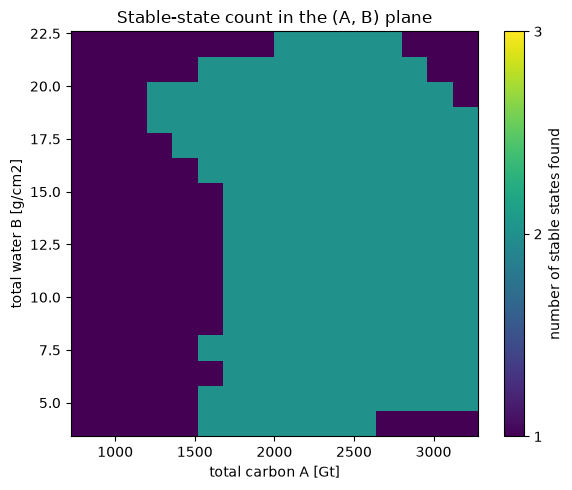

In [13]:
A_range = np.linspace(800, 3200, 16)
B_range = np.linspace(4, 22, 16)
initial_conditions = [(-40, 10, 2), (10, 10, 2), (20, 900, 3), (35, 1300, 5)]

n_states = np.zeros((len(B_range), len(A_range)))
for bi, B in enumerate(B_range):
    for ai, A in enumerate(A_range):
        labels = set()
        for T0, N0, Wa0 in initial_conditions:
            sol = run(T0=T0, N0=N0, Wa0=Wa0, A=A, B=B, t_end=250)
            Tf, Nf, _ = sol.y[:, -1]
            labels.add(classify(Tf, Nf))
        n_states[bi, ai] = len(labels)

fig, ax = plt.subplots(figsize=(6, 5))
pc = ax.pcolormesh(A_range, B_range, n_states, cmap="viridis", shading="nearest", vmin=1, vmax=3)
cbar = fig.colorbar(pc, ax=ax, ticks=[1, 2, 3])
cbar.set_label("number of stable states found")
ax.set_xlabel("total carbon A [Gt]")
ax.set_ylabel("total water B [g/cm2]")
ax.set_title("Stable-state count in the (A, B) plane")
fig.tight_layout()

**How to read it.** This map compresses the whole basins-of-attraction experiment into
a single number. The axes are now the two conservation parameters &mdash; total carbon
$A$ across, total water $B$ up &mdash; and the colour is *how many distinct end states*
were reached when four very different initial conditions (cold and bare, warm and
bare, warm and vegetated, hot and heavily vegetated) were each integrated forward from
that $(A, B)$ point. **Dark purple** means all four runs converged to the *same* state:
the system is **monostable**, its climate uniquely fixes its vegetation. **Teal** means
the runs split between two attractors: the system is **bistable** and history decides
the outcome.

**What the map shows.**

- A roughly vertical front near $A \approx 1400$&ndash;$1600$ Gt separates a monostable
  low-carbon region (only the desert is stable) from a bistable higher-carbon region
  (desert *and* forest both stable).
- Because that front is nearly vertical, **carbon is the dominant control**: whether
  history matters is set mainly by how much carbon the system holds.
- Water has a weaker, second-order effect &mdash; the front leans slightly towards
  higher $A$ as $B$ increases through the mid-range, and in the driest
  ($B \lesssim 5$) and wettest ($B \gtrsim 21$) rows the bistable region is pinched
  back so that only one state survives.
- Nowhere is there a third colour: this reduced parameter set never produces three
  simultaneously stable states.

**What we infer.**

1. **The $A$&ndash;$B$ plane has two regimes.** A hydroclimate poor in carbon admits
   one possible biosphere; past a carbon threshold two become possible and the one that
   is realised is a matter of history.
2. **This is a parameter-space portrait of a tipping point.** The teal region is where
   a gradual change in $A$ or $B$, or a large enough disturbance to the vegetation, can
   flip the system between branches with no easy way back. Places whose real
   carbon&ndash;water budget puts them near this front are the ones most exposed to
   abrupt, hard-to-reverse ecosystem shifts.
3. **What the simplified model misses.** Svirezhev and von Bloh's full parameter set
   also yields a narrow *tristable* band, with a cold desert, a cold forest, and a hot
   forest all stable at once. The coefficients used here &mdash; chosen only to
   reproduce the overall bifurcation structure &mdash; merge the two vegetated branches
   into one, so that third region does not appear. Recovering it is left as an
   extension.


## 9) Summary

Starting from the two-variable climate-vegetation model of Svirezhev and von Bloh (1996), adding a carbon cycle (Svirezhev & von Bloh, 1997) and then a hydrological cycle (Svirezhev & von Bloh, 1998) turns a system with at most two stable climates into one whose number of stable climates depends on how much carbon and water the planet has to work with. The mechanism is the same ice-albedo-type positive feedback already met in Lecture 5, now joined by a second, biotic feedback: vegetation lowers albedo and raises evapotranspiration, so that a planet warm and wet enough to support plant growth tends to stay that way, while a planet that loses its vegetation loses this stabilising effect and can drift toward the cold, bare state. As in Lecture 5, the practical lesson is that a system with several stable states can respond to a small, gradual change in a parameter, here the total carbon or water budget, with an abrupt shift from one climate to another once a threshold is crossed.

### References

Budyko, M. I. (1969). The effect of solar radiation variations on the climate of earth. *Tellus, 21*, 611–619.

Keeling, C. D. (1973). The carbon dioxide cycle: Reservoir models to depict the exchange of atmospheric carbon dioxide with the oceans and land plants. In S. I. Rasool (Ed.), *Chemistry in the lower atmosphere* (pp. 251–329). Plenum Press.

Mokhov, I. I., & Petoukhov, V. K. (1978). *Parametrization of thermal radiation fluxes for climatic models* (Preprint No. 3, 34). Institute of Atmospheric Physics, USSR Academy of Sciences.

Petoukhov, V. K., & Ganopolski, A. V. (1994). *A set of climate models for integrated modelling of climate change impacts. Part II: A 2.5-dimensional dynamical climate model* (WP-94-39). IIASA.

Smagorinsky, J. (1960). On the dynamical prediction of large-scale condensation by numerical methods. In *Physics of precipitation* (Monograph No. 5, pp. 71–78). American Geophysical Union.

Svirezhev, Y. M., & von Bloh, W. (1996). A minimal model of interaction between climate and vegetation: Qualitative approach. *Ecological Modelling, 92*(1), 89–99.

Svirezhev, Y. M., & von Bloh, W. (1997). Climate, vegetation, and global carbon cycle: The simplest zero-dimensional model. *Ecological Modelling, 101*, 79–92.

Svirezhev, Y. M., & von Bloh, W. (1998). A zero-dimensional climate-vegetation model containing global carbon and hydrological cycle. *Ecological Modelling, 106*, 119–127.


```{note} Sources
The model is that of Svirezhev & von Bloh (1998); the references are in Section 1. The
notebook is adapted from the
[*Climate of the Ocean*](https://github.com/florianboergel/climateoftheocean) course,
for **CE524 Applied Hydroclimatology**.

Text under CC BY-SA 4.0; full attribution and per-lecture provenance in
[CREDITS.md](https://github.com/drvivekhydro/hydroclimatology/blob/main/CREDITS.md).
```
